<a href="https://colab.research.google.com/github/DienAkbar25/DesainAnalisisAlgoritma/blob/Aul/DAA(TRIP_PLANNER).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import time
from itertools import combinations

In [42]:
places = {
    1: "Malioboro",
    2: "Tugu Jogja",
    3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta",
    5: "Taman Sari",
    6: "Museum Sonobudoyo",
    7: "Candi Prambanan",
    8: "Ratu Boko",
    9: "Tebing Breksi",
    10: "Kaliurang",
    11: "Basecamp Lava Tour Merapi",
    12: "Museum Ullen Sentalu",
    13: "Pantai Parang Teritis",
    14: "HeHa Sky View",
    15: "Hutam Pinus Pengger"
}

In [43]:
day = {
    1: 1, 2: 1, 3: 1,
    4: 2, 5: 2, 6: 2,
    7: 3, 8: 3, 9: 3,
    10: 4, 11: 4, 12: 4,
    13: 5, 14: 5, 15: 5
}

N = len(places)

In [44]:
order_by_day = {}
for d in sorted(set(day.values())):
    order_by_day[d] = sorted([n for n,t in day.items() if t == d])

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())

for i, d in enumerate(days_sorted):
    seq = order_by_day[d]

    # chain dalam 1 hari
    for j in range(len(seq) - 1):
        linear_graph[seq[j]].append((seq[j+1], 1))

    # connect ke hari berikutnya
    if i < len(days_sorted) - 1:
        last = seq[-1]
        next_first = order_by_day[days_sorted[i+1]][0]
        linear_graph[last].append((next_first, 1))

print("Linear adjacency list:\n")
for u in sorted(linear_graph.keys()):
    print(f"{u:2d} -> {linear_graph[u]}")

Linear adjacency list:

 1 -> [(2, 1)]
 2 -> [(3, 1)]
 3 -> [(4, 1)]
 4 -> [(5, 1)]
 5 -> [(6, 1)]
 6 -> [(7, 1)]
 7 -> [(8, 1)]
 8 -> [(9, 1)]
 9 -> [(10, 1)]
10 -> [(11, 1)]
11 -> [(12, 1)]
12 -> [(13, 1)]
13 -> [(14, 1)]
14 -> [(15, 1)]
15 -> []


In [45]:
def linear_pos(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())

    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1) / 2
        for j, node in enumerate(seq):
            y = (mid - j) * y_step
            pos[node] = (x, y)

    return pos

pos = linear_pos(order_by_day)

In [46]:
def topo_kahn(adj):
    indeg = {n: 0 for n in adj}
    for u, edges in adj.items():
        for v, w in edges:
            indeg[v] += 1

    dq = deque([n for n in indeg if indeg[n] == 0])
    res = []

    while dq:
        u = dq.popleft()
        res.append(u)
        for v, w in adj[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                dq.append(v)
    return res


def topo_dfs(adj):
    visited = {n: False for n in adj}
    stack = []

    def dfs(u):
        visited[u] = True
        for v, w in adj[u]:
            if not visited[v]:
                dfs(v)
        stack.append(u)

    for n in sorted(adj.keys()):
        if not visited[n]:
            dfs(n)

    return list(reversed(stack))


In [47]:
def kendall_stability(a, b):
    assert set(a) == set(b)
    pos_b = {v: i for i, v in enumerate(b)}

    n = len(a)
    discord = 0
    total = 0

    for i, j in combinations(range(n), 2):
        u = a[i]; v = a[j]
        if pos_b[u] > pos_b[v]:
            discord += 1
        total += 1

    return 1 - (discord / total)

In [48]:
start = time.time()
order_kahn = topo_kahn(linear_graph)
time_kahn = (time.time() - start) * 1000

start = time.time()
order_dfs = topo_dfs(linear_graph)
time_dfs = (time.time() - start) * 1000

# stability
stability = kendall_stability(order_kahn, order_dfs)

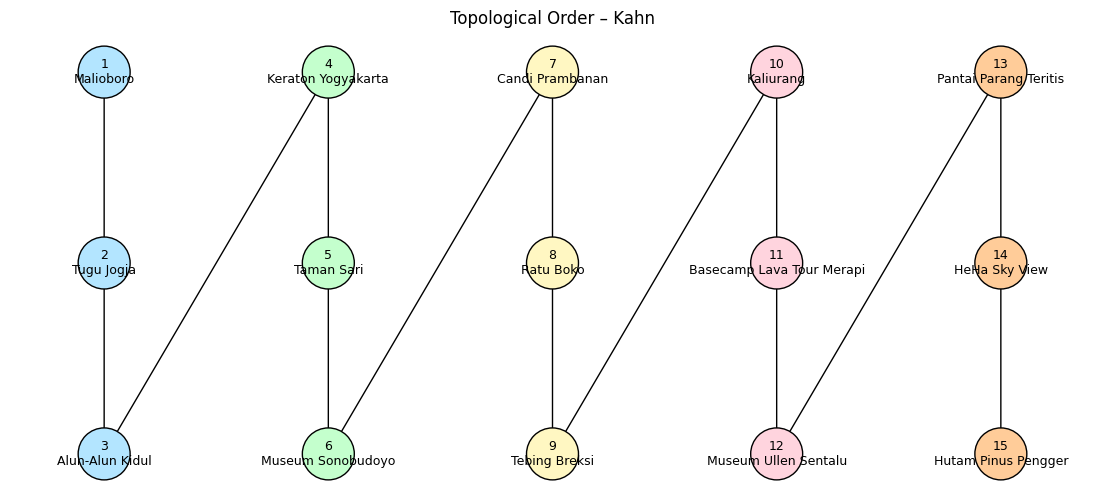

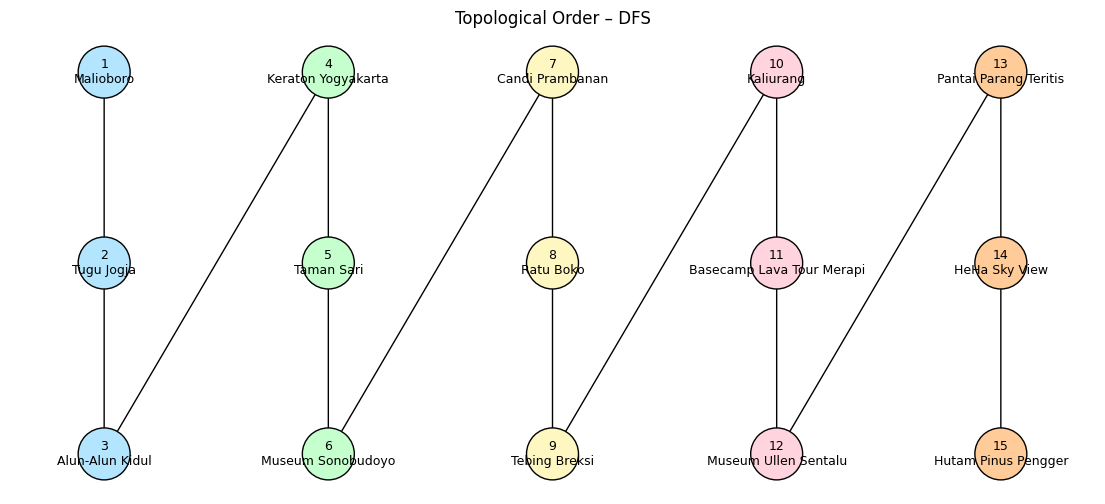

In [49]:
def draw_topo(order, title):
    G = nx.DiGraph()
    for u, edges in linear_graph.items():
        for v, w in edges:
            G.add_edge(u, v, weight=w)

    rank = {node: i+1 for i, node in enumerate(order)}

    colors = {
        1:"#b3e5ff", 2:"#c4ffcd", 3:"#fff7c2",
        4:"#ffd4de", 5:"#ffcc99"
    }
    node_colors = [colors[day[n]] for n in G.nodes()]

    plt.figure(figsize=(14,6))
    nx.draw_networkx_nodes(G, pos, node_size=1400,
                           node_color=node_colors, edgecolors="black")
    nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=16)

    labels = {n: f"{rank[n]}\n{places[n]}" for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title(title)
    plt.axis("off")
    plt.show()

# draw
draw_topo(order_kahn, "Topological Order – Kahn")
draw_topo(order_dfs, "Topological Order – DFS")

In [50]:
print("\n==================== HASIL ====================")
print("Kahn:", order_kahn)
print("DFS :", order_dfs)
print()
print(f"Runtime Kahn : {time_kahn:.6f} ms")
print(f"Runtime DFS  : {time_dfs:.6f} ms")
print(f"Stability    : {stability:.4f} (1 = identical)")
print("=================================================")


==================== HASIL ====================
Kahn: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
DFS : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Runtime Kahn : 0.106096 ms
Runtime DFS  : 0.080109 ms
Stability    : 1.0000 (1 = identical)


In [53]:
!pip install ipywidgets
from google.colab import output
output.enable_custom_widget_manager()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.0 MB/s eta 0:00:00


In [66]:
import networkx as nx
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output
import ipywidgets as widgets
from itertools import combinations
from collections import deque

# ============================================================
# DATA SESUAI PUNYAMU
# ============================================================

places = {
    1: "Malioboro", 2: "Tugu Jogja", 3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta", 5: "Taman Sari", 6: "Museum Sonobudoyo",
    7: "Candi Prambanan", 8: "Ratu Boko", 9: "Tebing Breksi",
    10: "Kaliurang", 11: "Basecamp Lava Tour Merapi", 12: "Museum Ullen Sentalu",
    13: "Pantai Parang Teritis", 14: "HeHa Sky View", 15: "Hutam Pinus Pengger"
}

day = {
    1:1,2:1,3:1,
    4:2,5:2,6:2,
    7:3,8:3,9:3,
    10:4,11:4,12:4,
    13:5,14:5,15:5
}

# ============================================================
# BUILD linear_graph (PUNYAMU)
# ============================================================
order_by_day = {}
for d in sorted(set(day.values())):
    order_by_day[d] = sorted([n for n,t in day.items() if t == d])

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())

for i, d in enumerate(days_sorted):
    seq = order_by_day[d]

    for j in range(len(seq)-1):
        linear_graph[seq[j]].append((seq[j+1], 1))

    if i < len(days_sorted)-1:
        linear_graph[seq[-1]].append((order_by_day[days_sorted[i+1]][0],1))

# ============================================================
# POSISI NODE SESUAI PUNYAMU
# ============================================================
def linear_pos(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())

    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1)/2
        for j, node in enumerate(seq):
            y = (mid - j)*y_step
            pos[node] = (x, y)
    return pos

pos = linear_pos(order_by_day)

# ============================================================
# TOPOLOGICAL SORT (PUNYAMU)
# ============================================================
def topo_kahn(adj):
    indeg = {n:0 for n in adj}
    for u, edges in adj.items():
        for v,_ in edges:
            indeg[v]+=1

    dq = deque([n for n in indeg if indeg[n]==0])
    res = []

    while dq:
        u = dq.popleft()
        res.append(u)
        for v,_ in adj[u]:
            indeg[v]-=1
            if indeg[v]==0:
                dq.append(v)
    return res

def topo_dfs(adj):
    vis = {n:False for n in adj}
    st = []

    def dfs(u):
        vis[u] = True
        for v,_ in adj[u]:
            if not vis[v]:
                dfs(v)
        st.append(u)

    for n in sorted(adj.keys()):
        if not vis[n]:
            dfs(n)

    return list(reversed(st))

# ============================================================
# BUILD NETWORKX GRAPH
# ============================================================
G = nx.DiGraph()
for u,edges in linear_graph.items():
    for v,w in edges:
        G.add_edge(u,v,weight=w)

# ============================================================
# VISUALISASI
# ============================================================

colors = {
    1:"#b3e5ff", 2:"#c4ffcd", 3:"#fff7c2",
    4:"#ffd4de", 5:"#ffcc99"
}

# ---------------------- GRAF NORMAL -------------------------
def draw_graph(highlight=None, finished=set(), title="Graf"):
    clear_output(wait=True)
    plt.figure(figsize=(14,6))

    node_colors = []
    for n in G.nodes():
        if n in finished:
            node_colors.append("lightgreen")
        elif n == highlight:
            node_colors.append("orange")
        else:
            node_colors.append(colors[day[n]])

    # LABEL: nomor + nama
    labels = {n: f"{n}\n{places[n]}" for n in G.nodes()}

    nx.draw(
        G, pos,
        node_color=node_colors,
        edgecolors="black",
        with_labels=True,
        labels=labels,
        node_size=1500,
        arrowsize=15
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

# ---------------------- STATIC ORDER -------------------------
def draw_order_static(order, title):
    clear_output(wait=True)
    plt.figure(figsize=(14,6))

    rank = {node:i+1 for i,node in enumerate(order)}

    labels = {n: f"{rank[n]}\n{n} - {places[n]}" for n in G.nodes()}

    nx.draw_networkx_nodes(
        G, pos,
        node_size=1500,
        node_color=[colors[day[n]] for n in G.nodes()],
        edgecolors="black"
    )
    nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=16)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.show()

# ---------------------- ANIMASI -------------------------
def animate(order, algo):
    finished = set()
    for node in order:
        draw_graph(highlight=node, finished=finished, title=f"Animasi {algo}")
        time.sleep(1)
        finished.add(node)
    draw_graph(finished=finished, title=f"{algo} — Selesai!")


# ============================================================
# GUI WIDGET
# ============================================================

btn_show = widgets.Button(description="📌 Tampilkan Graf")
btn_kahn = widgets.Button(description="▶️ Animasi Kahn")
btn_dfs = widgets.Button(description="▶️ Animasi DFS")
btn_order_kahn = widgets.Button(description="📊 Static Order Kahn")
btn_order_dfs = widgets.Button(description="📊 Static Order DFS")
output_area = widgets.Output()

def show_graph(_):
    with output_area:
        draw_graph(title="Graf Linear By-Day")

def run_kahn(_):
    with output_area:
        animate(topo_kahn(linear_graph), "Kahn")

def run_dfs(_):
    with output_area:
        animate(topo_dfs(linear_graph), "DFS")

def show_static_kahn(_):
    with output_area:
        draw_order_static(topo_kahn(linear_graph), "Topological Order – Kahn")

def show_static_dfs(_):
    with output_area:
        draw_order_static(topo_dfs(linear_graph), "Topological Order – DFS")

btn_show.on_click(show_graph)
btn_kahn.on_click(run_kahn)
btn_dfs.on_click(run_dfs)
btn_order_kahn.on_click(show_static_kahn)
btn_order_dfs.on_click(show_static_dfs)

display(widgets.HBox([btn_show, btn_kahn, btn_dfs]))
display(widgets.HBox([btn_order_kahn, btn_order_dfs]))
display(output_area)


Output()

In [67]:
import networkx as nx
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output
import ipywidgets as widgets
from collections import deque

# ============================================================
# DATA SESUAI PUNYAMU
# ============================================================

places = {
    1: "Malioboro", 2: "Tugu Jogja", 3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta", 5: "Taman Sari", 6: "Museum Sonobudoyo",
    7: "Candi Prambanan", 8: "Ratu Boko", 9: "Tebing Breksi",
    10: "Kaliurang", 11: "Basecamp Lava Tour Merapi", 12: "Museum Ullen Sentalu",
    13: "Pantai Parang Teritis", 14: "HeHa Sky View", 15: "Hutam Pinus Pengger"
}

day = {
    1:1,2:1,3:1,
    4:2,5:2,6:2,
    7:3,8:3,9:3,
    10:4,11:4,12:4,
    13:5,14:5,15:5
}

# ============================================================
# BUILD linear_graph (PUNYAMU)
# ============================================================
order_by_day = {}
for d in sorted(set(day.values())):
    order_by_day[d] = sorted([n for n,t in day.items() if t == d])

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())

for i, d in enumerate(days_sorted):
    seq = order_by_day[d]

    # sambung dalam 1 hari
    for j in range(len(seq)-1):
        linear_graph[seq[j]].append((seq[j+1], 1))

    # sambung hari terakhir ke hari berikut
    if i < len(days_sorted)-1:
        linear_graph[seq[-1]].append((order_by_day[days_sorted[i+1]][0],1))

# ============================================================
# POSISI NODE SESUAI PUNYAMU
# ============================================================
def linear_pos(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())

    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1)/2
        for j, node in enumerate(seq):
            y = (mid - j)*y_step
            pos[node] = (x, y)
    return pos

pos = linear_pos(order_by_day)

# ============================================================
# TOPOLOGICAL SORT (PUNYAMU)
# ============================================================
def topo_kahn(adj):
    indeg = {n:0 for n in adj}
    for u, edges in adj.items():
        for v,_ in edges:
            indeg[v]+=1

    dq = deque([n for n in indeg if indeg[n]==0])
    res = []

    while dq:
        u = dq.popleft()
        res.append(u)
        for v,_ in adj[u]:
            indeg[v]-=1
            if indeg[v]==0:
                dq.append(v)
    return res

def topo_dfs(adj):
    vis = {n:False for n in adj}
    st = []

    def dfs(u):
        vis[u] = True
        for v,_ in adj[u]:
            if not vis[v]:
                dfs(v)
        st.append(u)

    for n in sorted(adj.keys()):
        if not vis[n]:
            dfs(n)

    return list(reversed(st))

# ============================================================
# BUILD NETWORKX GRAPH
# ============================================================
G = nx.DiGraph()
for u,edges in linear_graph.items():
    for v,w in edges:
        G.add_edge(u,v,weight=w)

# ============================================================
# VISUALISASI
# ============================================================

colors = {
    1:"#b3e5ff", 2:"#c4ffcd", 3:"#fff7c2",
    4:"#ffd4de", 5:"#ffcc99"
}

# ---------------------- GRAF NORMAL / SISA NODE -------------------------
def draw_graph(remaining_nodes=None, highlight=None, title="Graf"):
    """
    remaining_nodes: himpunan node yang masih ada di graf.
                     Kalau None -> pakai semua node (awal).
    highlight: node yang sedang diproses (warna oranye).
    """
    clear_output(wait=True)
    plt.figure(figsize=(14,6))

    if remaining_nodes is None:
        remaining_nodes = set(G.nodes())

    subG = G.subgraph(remaining_nodes)

    node_colors = []
    for n in subG.nodes():
        if n == highlight:
            node_colors.append("orange")
        else:
            node_colors.append(colors[day[n]])

    labels = {n: f"{n}\n{places[n]}" for n in subG.nodes()}

    nx.draw(
        subG, pos,
        node_color=node_colors,
        edgecolors="black",
        with_labels=True,
        labels=labels,
        node_size=1500,
        arrowsize=15
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

# ---------------------- STATIC ORDER -------------------------
def draw_order_static(order, title):
    clear_output(wait=True)
    plt.figure(figsize=(14,6))

    rank = {node:i+1 for i,node in enumerate(order)}
    labels = {n: f"{rank[n]}\n{n} - {places[n]}" for n in G.nodes()}

    nx.draw_networkx_nodes(
        G, pos,
        node_size=1500,
        node_color=[colors[day[n]] for n in G.nodes()],
        edgecolors="black"
    )
    nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=16)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.show()

# ---------------------- ANIMASI (NODE YANG SUDAH LEWAT = ILANG) -------------------------
def animate(order, algo):
    # semua node masih ada di awal
    remaining = set(G.nodes())

    for node in order:
        # 1) tampilkan node yang sedang diproses (masih ada di graf)
        draw_graph(remaining_nodes=remaining, highlight=node, title=f"Animasi {algo} – proses {node}")
        time.sleep(1.0)

        # 2) hapus node dari graf (ilang)
        if node in remaining:
            remaining.remove(node)
        draw_graph(remaining_nodes=remaining, highlight=None, title=f"Animasi {algo} – {node} dihapus")
        time.sleep(0.5)

    # terakhir: semua node sudah dihapus (graf kosong)
    draw_graph(remaining_nodes=remaining, highlight=None, title=f"{algo} — Selesai! (semua node sudah diambil)")

# ============================================================
# GUI WIDGET
# ============================================================

btn_show = widgets.Button(description="📌 Tampilkan Graf Awal")
btn_kahn = widgets.Button(description="▶️ Animasi Kahn")
btn_dfs = widgets.Button(description="▶️ Animasi DFS")
btn_order_kahn = widgets.Button(description="📊 Static Order Kahn")
btn_order_dfs = widgets.Button(description="📊 Static Order DFS")
output_area = widgets.Output()

def show_graph(_):
    with output_area:
        draw_graph(title="Graf Linear By-Day (Semua Node)")

def run_kahn(_):
    with output_area:
        animate(topo_kahn(linear_graph), "Kahn")

def run_dfs(_):
    with output_area:
        animate(topo_dfs(linear_graph), "DFS")

def show_static_kahn(_):
    with output_area:
        draw_order_static(topo_kahn(linear_graph), "Topological Order – Kahn")

def show_static_dfs(_):
    with output_area:
        draw_order_static(topo_dfs(linear_graph), "Topological Order – DFS")

btn_show.on_click(show_graph)
btn_kahn.on_click(run_kahn)
btn_dfs.on_click(run_dfs)
btn_order_kahn.on_click(show_static_kahn)
btn_order_dfs.on_click(show_static_dfs)

display(widgets.HBox([btn_show, btn_kahn, btn_dfs]))
display(widgets.HBox([btn_order_kahn, btn_order_dfs]))
display(output_area)


Output()

In [68]:
# ==== SETUP UNTUK COLAB (WIDGET) ====
!pip install ipywidgets
from google.colab import output
output.enable_custom_widget_manager()

import networkx as nx
import matplotlib.pyplot as plt
import time
from IPython.display import display
import ipywidgets as widgets
from collections import deque

# ============================================================
# DATA TEMPAT & HARI (PUNYAMU)
# ============================================================

places = {
    1: "Malioboro", 2: "Tugu Jogja", 3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta", 5: "Taman Sari", 6: "Museum Sonobudoyo",
    7: "Candi Prambanan", 8: "Ratu Boko", 9: "Tebing Breksi",
    10: "Kaliurang", 11: "Basecamp Lava Tour Merapi",
    12: "Museum Ullen Sentalu", 13: "Pantai Parang Teritis",
    14: "HeHa Sky View", 15: "Hutan Pinus Pengger"
}

day = {
    1:1,2:1,3:1,
    4:2,5:2,6:2,
    7:3,8:3,9:3,
    10:4,11:4,12:4,
    13:5,14:5,15:5
}

# ============================================================
# BUILD linear_graph (sesuai id per hari, lalu sambung antar hari)
# ============================================================
order_by_day = {}
for d in sorted(set(day.values())):
    order_by_day[d] = sorted([n for n, t in day.items() if t == d])

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())

for i, d in enumerate(days_sorted):
    seq = order_by_day[d]

    # sambung node dalam 1 hari
    for j in range(len(seq) - 1):
        linear_graph[seq[j]].append((seq[j+1], 1))

    # sambung hari terakhir ke node pertama hari berikutnya
    if i < len(days_sorted) - 1:
        linear_graph[seq[-1]].append((order_by_day[days_sorted[i+1]][0], 1))

# ============================================================
# POSISI NODE (layout linear per hari)
# ============================================================
def linear_pos(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())

    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1) / 2
        for j, node in enumerate(seq):
            y = (mid - j) * y_step
            pos[node] = (x, y)
    return pos

pos = linear_pos(order_by_day)

# ============================================================
# TOPOLOGICAL SORT: KAHN & DFS (BENAR SESUAI TEORI)
# ============================================================
def topo_kahn(adj):
    # hitung indegree
    indeg = {n: 0 for n in adj}
    for u, edges in adj.items():
        for v, _ in edges:
            indeg[v] += 1

    dq = deque([n for n in indeg if indeg[n] == 0])
    res = []

    while dq:
        u = dq.popleft()
        res.append(u)
        for v, _ in adj[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                dq.append(v)
    return res

def topo_dfs(adj):
    vis = {n: False for n in adj}
    st = []

    def dfs(u):
        vis[u] = True
        for v, _ in adj[u]:
            if not vis[v]:
                dfs(v)
        # post-order: push saat pulang
        st.append(u)

    for n in sorted(adj.keys()):
        if not vis[n]:
            dfs(n)

    # stack dibalik → topological order
    return list(reversed(st))

# ============================================================
# BUILD NETWORKX GRAPH DARI linear_graph
# ============================================================
G = nx.DiGraph()
for u, edges in linear_graph.items():
    for v, w in edges:
        G.add_edge(u, v, weight=w)

# ============================================================
# VISUALISASI: WARNA PER HARI
# ============================================================
colors = {
    1: "#b3e5ff",  # hari 1
    2: "#c4ffcd",  # hari 2
    3: "#fff7c2",  # hari 3
    4: "#ffd4de",  # hari 4
    5: "#ffcc99"   # hari 5
}

def draw_graph(remaining_nodes=None, highlight=None, title="Graf"):
    """
    remaining_nodes: node yang masih ada di graf (set).
    highlight: node yang sedang diproses (diwarnai oranye).
    """
    if remaining_nodes is None:
        remaining_nodes = set(G.nodes())

    subG = G.subgraph(remaining_nodes)

    fig, ax = plt.subplots(figsize=(14, 6))

    # warna node
    node_colors = []
    for n in subG.nodes():
        if n == highlight:
            node_colors.append("orange")
        else:
            node_colors.append(colors[day[n]])

    labels = {n: f"{n}\n{places[n]}" for n in subG.nodes()}

    nx.draw(
        subG, pos,
        node_color=node_colors,
        edgecolors="black",
        with_labels=True,
        labels=labels,
        node_size=1500,
        arrowsize=15,
        ax=ax
    )

    ax.set_title(title)
    ax.axis("off")
    return fig

def draw_order_static(order, title):
    """
    Menampilkan urutan topo (statis):
    label node = urutan ke-berapa + nama.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    rank = {node: i+1 for i, node in enumerate(order)}
    labels = {n: f"{rank[n]}\n{n} - {places[n]}" for n in G.nodes()}

    nx.draw_networkx_nodes(
        G, pos,
        node_size=1500,
        node_color=[colors[day[n]] for n in G.nodes()],
        edgecolors="black",
        ax=ax
    )
    nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=16, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

    ax.set_title(title)
    ax.axis("off")
    return fig

# ============================================================
# ANIMASI: NODE YANG SUDAH LEWAT = HILANG DARI GRAF
# ============================================================
output_area = widgets.Output()
delay_slider = widgets.FloatSlider(
    value=1.0, min=0.1, max=2.0, step=0.1,
    description="Delay (detik):"
)

def animate(order, algo):
    remaining = set(G.nodes())

    for node in order:
        # 1) tampilkan node yang sedang diproses
        with output_area:
            output_area.clear_output(wait=True)
            fig = draw_graph(
                remaining_nodes=remaining,
                highlight=node,
                title=f"Animasi {algo} – proses node {node} ({places[node]})"
            )
            display(fig)
            plt.close(fig)
        time.sleep(delay_slider.value)

        # 2) hapus node dari graf (hilang)
        if node in remaining:
            remaining.remove(node)
        with output_area:
            output_area.clear_output(wait=True)
            fig = draw_graph(
                remaining_nodes=remaining,
                highlight=None,
                title=f"Animasi {algo} – node {node} dihapus"
            )
            display(fig)
            plt.close(fig)
        time.sleep(delay_slider.value * 0.5)

    # frame terakhir: semua node sudah diambil (graf bisa kosong)
    with output_area:
        output_area.clear_output(wait=True)
        fig = draw_graph(
            remaining_nodes=remaining,
            highlight=None,
            title=f"{algo} — Selesai! Semua node sudah diambil (topological order)."
        )
        display(fig)
        plt.close(fig)

# ============================================================
# GUI WIDGET
# ============================================================
btn_show = widgets.Button(description="📌 Tampilkan Graf Awal")
btn_kahn = widgets.Button(description="▶️ Animasi Kahn")
btn_dfs = widgets.Button(description="▶️ Animasi DFS")
btn_order_kahn = widgets.Button(description="📊 Static Order Kahn")
btn_order_dfs = widgets.Button(description="📊 Static Order DFS")

def show_graph(_):
    with output_area:
        output_area.clear_output(wait=True)
        fig = draw_graph(title="Graf Linear By-Day (Semua Node)")
        display(fig)
        plt.close(fig)

def run_kahn(_):
    order = topo_kahn(linear_graph)
    with output_area:
        output_area.clear_output(wait=True)
        print("Urutan Topological (Kahn):", order)
    animate(order, "Kahn")

def run_dfs(_):
    order = topo_dfs(linear_graph)
    with output_area:
        output_area.clear_output(wait=True)
        print("Urutan Topological (DFS):", order)
    animate(order, "DFS")

def show_static_kahn(_):
    order = topo_kahn(linear_graph)
    with output_area:
        output_area.clear_output(wait=True)
        fig = draw_order_static(order, "Topological Order – Kahn")
        display(fig)
        plt.close(fig)

def show_static_dfs(_):
    order = topo_dfs(linear_graph)
    with output_area:
        output_area.clear_output(wait=True)
        fig = draw_order_static(order, "Topological Order – DFS")
        display(fig)
        plt.close(fig)

btn_show.on_click(show_graph)
btn_kahn.on_click(run_kahn)
btn_dfs.on_click(run_dfs)
btn_order_kahn.on_click(show_static_kahn)
btn_order_dfs.on_click(show_static_dfs)

controls1 = widgets.HBox([btn_show, btn_kahn, btn_dfs])
controls2 = widgets.HBox([btn_order_kahn, btn_order_dfs, delay_slider])

display(controls1)
display(controls2)
display(output_area)

# tampilkan graf awal sekali di awal
with output_area:
    output_area.clear_output(wait=True)
    fig = draw_graph(title="Graf Linear By-Day (Semua Node)")
    display(fig)
    plt.close(fig)


Output()

Output()

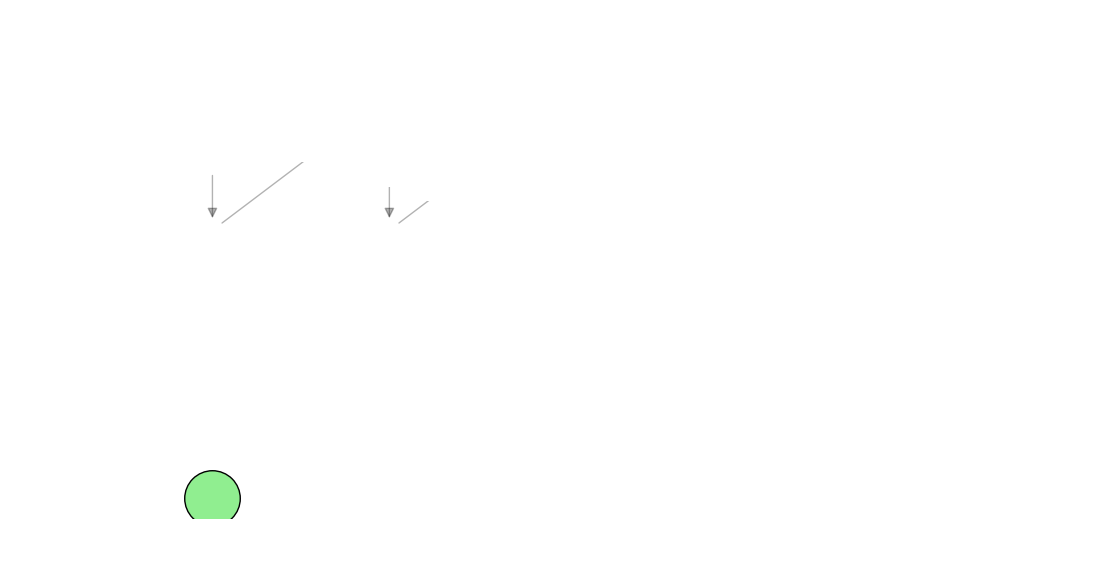

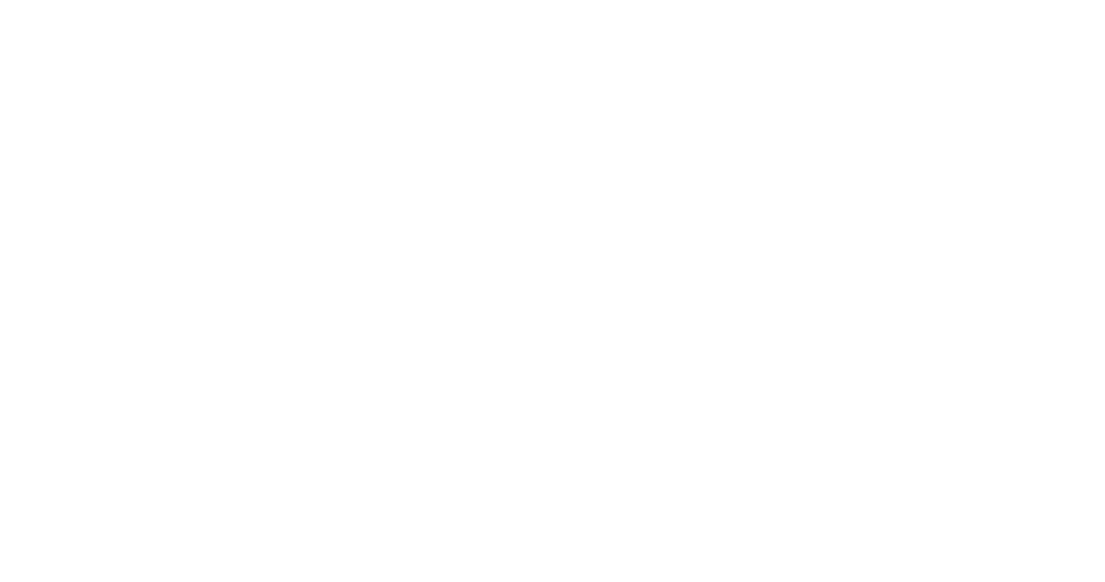

In [69]:
!pip install ipywidgets
from google.colab import output
output.enable_custom_widget_manager()

import networkx as nx
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from collections import deque
import threading, time

# ====================== DATA ======================
places = {
    1:"Malioboro",2:"Tugu Jogja",3:"Alun-Alun Kidul",
    4:"Keraton Yogyakarta",5:"Taman Sari",6:"Museum Sonobudoyo",
    7:"Candi Prambanan",8:"Ratu Boko",9:"Tebing Breksi",
    10:"Kaliurang",11:"Basecamp Lava Tour Merapi",
    12:"Museum Ullen Sentalu",13:"Pantai Parang Teritis",
    14:"HeHa Sky View",15:"Hutan Pinus Pengger"
}

day = {1:1,2:1,3:1,4:2,5:2,6:2,7:3,8:3,9:3,10:4,11:4,12:4,13:5,14:5,15:5}

colors = {
    1:"#b3e5ff", 2:"#c4ffcd", 3:"#fff7c2",
    4:"#ffd4de", 5:"#ffcc99"
}

# ====================== BANGUN GRAPH ======================
order_by_day = {d:sorted([n for n,t in day.items() if t==d])
                for d in sorted(set(day.values()))}

linear_graph = {n:[] for n in places}
ds = list(order_by_day)

for i,d in enumerate(ds):
    seq = order_by_day[d]
    for j in range(len(seq)-1):
        linear_graph[seq[j]].append((seq[j+1],1))
    if i < len(ds)-1:
        linear_graph[seq[-1]].append((order_by_day[ds[i+1]][0],1))

G = nx.DiGraph()
for u,edges in linear_graph.items():
    for v,_ in edges:
        G.add_edge(u,v)

# ====================== POS UTAMA ======================
# posisi atas (graf asli)
def pos_top():
    pos={}
    xstep, ystep = 3, 2
    maxlen = max(len(v) for v in order_by_day.values())
    for i,d in enumerate(order_by_day):
        seq = order_by_day[d]
        mid = (maxlen-1)/2
        for j,n in enumerate(seq):
            pos[n]=(i*xstep, (mid-j)*ystep + 10)   # posisi tinggi
    return pos

# posisi bawah (hasil topo)
def pos_bottom(sorted_list):
    pos={}
    for i,n in enumerate(sorted_list):
        pos[n]=(i*3, 0)           # line output
    return pos

# ====================== FRAMES KAHN ======================
def build_frames_kahn(adj):
    indeg={n:0 for n in adj}
    for u,edges in adj.items():
        for v,_ in edges: indeg[v]+=1

    q = deque(sorted([n for n in adj if indeg[n]==0]))

    frames=[]
    sorted_list=[]
    remaining=set(adj.keys())

    frames.append({"sorted":sorted_list.copy(),"sel":None,"edge":None,
                   "remain":remaining.copy(),"msg":"Mulai Kahn"})

    while q:
        u=q.popleft()

        # highlight node yg dipilih
        frames.append({"sorted":sorted_list.copy(),"sel":u,"edge":None,
                       "remain":remaining.copy(),"msg":f"Pilih {u}"})

        # hapus edge keluar satu per satu
        for v,_ in adj[u]:
            frames.append({"sorted":sorted_list.copy(),"sel":u,"edge":(u,v),
                           "remain":remaining.copy(),"msg":f"Hapus edge {u}→{v}"})

            indeg[v]-=1
            if indeg[v]==0:
                q.append(v)

        # MASUKKAN ke hasil
        sorted_list.append(u)
        remaining.remove(u)
        frames.append({"sorted":sorted_list.copy(),"sel":None,"edge":None,
                       "remain":remaining.copy(),"msg":f"{u} dimasukkan ke hasil"})

    frames.append({"sorted":sorted_list.copy(),"sel":None,"edge":None,
                   "remain":remaining.copy(),"msg":"Selesai"})
    return frames

# ====================== FRAMES DFS ======================
def build_frames_dfs(adj):
    visited=set()
    sorted_list=[]
    remaining=set(adj.keys())
    frames=[]

    frames.append({"sorted":sorted_list.copy(),"sel":None,"edge":None,
                   "remain":remaining.copy(),"msg":"Mulai DFS"})

    def dfs(u):
        visited.add(u)
        frames.append({"sorted":sorted_list.copy(),"sel":u,"edge":None,
                       "remain":remaining.copy(),"msg":f"Masuk {u}"})

        for v,_ in sorted(adj[u]):
            if v not in visited:
                frames.append({"sorted":sorted_list.copy(),"sel":u,"edge":(u,v),
                               "remain":remaining.copy(),"msg":f"DFS ke {v}"})
                dfs(v)
            else:
                frames.append({"sorted":sorted_list.copy(),"sel":u,"edge":(u,v),
                               "remain":remaining.copy(),"msg":f"Skip {v} (visited)"})

        # selesai → masukkan ke output
        sorted_list.append(u)
        remaining.remove(u)
        frames.append({"sorted":sorted_list.copy(),"sel":None,"edge":None,
                       "remain":remaining.copy(),"msg":f"{u} selesai & masuk hasil"})

    for n in sorted(adj):
        if n not in visited:
            dfs(n)

    frames.append({"sorted":sorted_list.copy(),"sel":None,"edge":None,
                   "remain":remaining.copy(),"msg":"Selesai"})
    return frames

frames_K = build_frames_kahn(linear_graph)
frames_D = build_frames_dfs(linear_graph)

# ====================== RENDER ======================
def draw_frame(F):
    plt.figure(figsize=(14,7))

    # posisi bagian atas dan bawah
    pos1 = pos_top()
    pos2 = pos_bottom(F["sorted"])

    # gabung posisi
    pos = pos1.copy()
    pos.update(pos2)

    # node remaining = masih di atas
    rem_nodes = list(F["remain"])
    out_nodes = F["sorted"]

    # gambar edges default
    nx.draw_networkx_edges(G.subgraph(rem_nodes), pos,
                           alpha=0.3, arrowsize=15)

    # edge aktif
    if F["edge"]:
        u,v=F["edge"]
        if u in rem_nodes:
            nx.draw_networkx_edges(G, pos, edgelist=[(u,v)],
                                   width=3, edge_color="red", arrowsize=20)

    # node atas
    nx.draw_networkx_nodes(G.subgraph(rem_nodes), pos,
                           node_color=[colors[day[n]] for n in rem_nodes],
                           node_size=1400, edgecolors="black")

    # node bawah (hasil topo)
    nx.draw_networkx_nodes(G.subgraph(out_nodes), pos2,
                           node_color="lightgreen", node_size=1600,
                           edgecolors="black")

    # highlight current selected node
    if F["sel"] in rem_nodes:
        nx.draw_networkx_nodes(G.subgraph([F["sel"]]), pos,
                               node_color="orange", node_size=1600,
                               edgecolors="black")

    # labels
    labels={n:f"{n}\n{places[n]}" for n in rem_nodes+out_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.title(F["msg"], fontsize=14)
    plt.axis("off")
    plt.show()

# ====================== GUI ======================
algo = widgets.Dropdown(options=["Kahn","DFS"], description="Algoritma:")
btn_prev = widgets.Button(description="⟵ Prev")
btn_next = widgets.Button(description="Next ⟶")
btn_play = widgets.ToggleButton(description="Auto ▶")
btn_reset = widgets.Button(description="Reset")
speed = widgets.FloatSlider(value=0.6, min=0.1, max=2, step=0.1, description="Delay")

out = widgets.Output()

state={"frames":frames_K, "i":0, "playing":False}

def show():
    out.clear_output(wait=True)
    with out:
        draw_frame(state["frames"][state["i"]])

def on_algo_change(ch):
    state["frames"] = frames_K if ch["new"]=="Kahn" else frames_D
    state["i"]=0
    show()

def prev_click(b):
    if state["i"]>0: state["i"]-=1
    show()

def next_click(b):
    if state["i"]<len(state["frames"])-1: state["i"]+=1
    show()

def autoplay():
    while state["playing"]:
        if state["i"] >= len(state["frames"])-1:
            state["playing"]=False; btn_play.value=False; btn_play.description="Auto ▶"
            break
        state["i"]+=1
        show()
        time.sleep(speed.value)

def toggle_play(ch):
    state["playing"] = ch["new"]
    if ch["new"]:
        btn_play.description="Stop ⏸"
        threading.Thread(target=autoplay, daemon=True).start()
    else:
        btn_play.description="Auto ▶"

def reset_click(b):
    state["i"]=0
    show()

algo.observe(on_algo_change, names="value")
btn_prev.on_click(prev_click)
btn_next.on_click(next_click)
btn_play.observe(toggle_play, names="value")
btn_reset.on_click(reset_click)

display(widgets.HBox([algo, btn_prev, btn_next, btn_play, btn_reset, speed]))
display(out)
show()
